Nossa missão e consolidar o banco de dados relacional, realizar a AED
Perguntas a serem respondidas:
1. Qual é a tendencia de volume de pedidos da Olist ao longo do tempo?
2. Como o custo médio do frete varia geograficamente pelo Brasil?
3. Qual é o impacto real e uantificável da demora na entrega sobre a nota de satisfação do cliente? comparação
4. Quais categorias do catalogo mais puxam a satisfação para baixo e sofrem com a complexidade da logística?

Passo a passo da EDA
Passo 1: Obtenção e leitura dos dados (Fonte: Kaggle)
Passo 2: Limpeza e quantidade de dados (Tratamento nulos e duplicatas)
Passo 3: Modelagem de dados (União das tabelas via merge)
Passo 4: Feature Engineering (Criação de métricas de atraso, SLAs e geográficas)
Passo 5: Exportação da base otimizada para Business Intelligence (Looker Studio)

In [1]:
import kagglehub
import pandas as pd
import numpy as np

#Importando base de dados Olist
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


### 1. CARREGAMENTO DOS DADOS


In [2]:
df_orders=pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")
df_items=pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
df_customers=pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
df_reviews=pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")
df_products=pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")




### 2. TRADUÇÃO DAS COLUNAS (DATA DICTIONARY)

In [3]:
map_orders = {
'order_id':'id_pedido',
'customer_id':'id_cliente',
'order_status':'status_pedido',
'order_purchase_timestamp':'data_compra',
'order_approved_at':'data_aprovacao',
'order_delivered_carrier_date':'data_envio_transportadora',
'order_delivered_customer_date':'data_entrega_cliente',
'order_estimated_delivery_date':'data_estimada_entrega'
}

map_items = {
'order_id':'id_pedido',
'product_id':'id_produto',
'seller_id':'id_vendedor',
'shipping_limit_date':'data_limite_envio',
'price':'preco_produto',
'freight_value':'valor_frete'
}
map_customers = {
'customer_id':'id_cliente',
'customer_city':'cidade_cliente',
'customer_state':'estado_cliente'
}

map_reviews = {
'order_id':'id_pedido',
'review_score':'nota_avaliacao'
}

map_products = {
'product_id':'id_produto',
'product_category_name':'categoria_produto'
}

#Aplicando as renomeações
df_orders.rename(columns=map_orders, inplace=True)
df_items.rename(columns=map_items, inplace=True)
df_customers.rename(columns=map_customers, inplace=True)
df_reviews.rename(columns=map_reviews, inplace=True)
df_products.rename(columns=map_products, inplace=True)
print("Colunas traduzidas para o português...")



Colunas traduzidas para o português...


### 3. LIMPEZA INICIAL

In [4]:
df_orders = df_orders[df_orders['status_pedido'] == 'delivered'].copy()
date_cols_orders = ["data_compra", "data_aprovacao", "data_envio_transportadora", "data_entrega_cliente", "data_estimada_entrega"]
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_items['data_limite_envio'] = pd.to_datetime(df_items['data_limite_envio'])

df_reviews_clean = df_reviews.groupby('id_pedido', as_index=False)['nota_avaliacao'].mean()


### 4. MERGE DAS TABELAS

In [5]:
df_main = df_orders.merge(df_customers[['id_cliente','cidade_cliente','estado_cliente']], on='id_cliente', how='left')
df_main.head()

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_estimada_entrega,cidade_cliente,estado_cliente
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP


In [6]:
df_main = df_main.merge(df_items[['id_pedido', 'id_produto', 'id_vendedor', 'data_limite_envio', 'preco_produto', 'valor_frete']], on='id_pedido', how='left')


In [7]:
df_main = df_main.merge(df_products[['id_produto','categoria_produto']], on='id_produto', how='left')


In [8]:
df_main=df_main.merge(df_reviews_clean, on='id_pedido', how='left')
df_main.head()

,id_pedido,id_cliente,status_pedido,data_compra,data_aprovacao,data_envio_transportadora,data_entrega_cliente,data_estimada_entrega,cidade_cliente,estado_cliente,id_produto,id_vendedor,data_limite_envio,preco_produto,valor_frete,categoria_produto,nota_avaliacao
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,5.0


In [9]:
df_main.dropna(subset=['data_entrega_cliente'], inplace=True)
print("Banco de dados consolidado")

Banco de dados consolidado


In [10]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 110196
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110189 non-null  object        
 1   id_cliente                 110189 non-null  object        
 2   status_pedido              110189 non-null  object        
 3   data_compra                110189 non-null  datetime64[ns]
 4   data_aprovacao             110174 non-null  datetime64[ns]
 5   data_envio_transportadora  110188 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_estimada_entrega      110189 non-null  datetime64[ns]
 8   cidade_cliente             110189 non-null  object        
 9   estado_cliente             110189 non-null  object        
 10  id_produto                 110189 non-null  object        
 11  id_vendedor                110189 non-null  object       

In [11]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_pedido                  96478 non-null  object        
 1   id_cliente                 96478 non-null  object        
 2   status_pedido              96478 non-null  object        
 3   data_compra                96478 non-null  datetime64[ns]
 4   data_aprovacao             96464 non-null  datetime64[ns]
 5   data_envio_transportadora  96476 non-null  datetime64[ns]
 6   data_entrega_cliente       96470 non-null  datetime64[ns]
 7   data_estimada_entrega      96478 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [12]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id_pedido          112650 non-null  object        
 1   order_item_id      112650 non-null  int64         
 2   id_produto         112650 non-null  object        
 3   id_vendedor        112650 non-null  object        
 4   data_limite_envio  112650 non-null  datetime64[ns]
 5   preco_produto      112650 non-null  float64       
 6   valor_frete        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [13]:
df_reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98673 entries, 0 to 98672
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_pedido       98673 non-null  object 
 1   nota_avaliacao  98673 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB


In [14]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_cliente                99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   cidade_cliente            99441 non-null  object
 4   estado_cliente            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


### 5. FEATURE ENGINEERING (REGRAS DE NEGÓCIO)

In [15]:
df_main['tempo_entrega_dias'] = (df_main['data_entrega_cliente'] - df_main['data_compra']).dt.days
df_main['atraso_entrega_dias'] = (df_main['data_entrega_cliente'] - df_main['data_estimada_entrega']).dt.days

In [16]:
df_main['categoria_produto'] = df_main['categoria_produto'].fillna('Nao informada')


In [17]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 110196
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_pedido                  110189 non-null  object        
 1   id_cliente                 110189 non-null  object        
 2   status_pedido              110189 non-null  object        
 3   data_compra                110189 non-null  datetime64[ns]
 4   data_aprovacao             110174 non-null  datetime64[ns]
 5   data_envio_transportadora  110188 non-null  datetime64[ns]
 6   data_entrega_cliente       110189 non-null  datetime64[ns]
 7   data_estimada_entrega      110189 non-null  datetime64[ns]
 8   cidade_cliente             110189 non-null  object        
 9   estado_cliente             110189 non-null  object        
 10  id_produto                 110189 non-null  object        
 11  id_vendedor                110189 non-null  object       

Iniciando Análise Exploratória de Negócios...


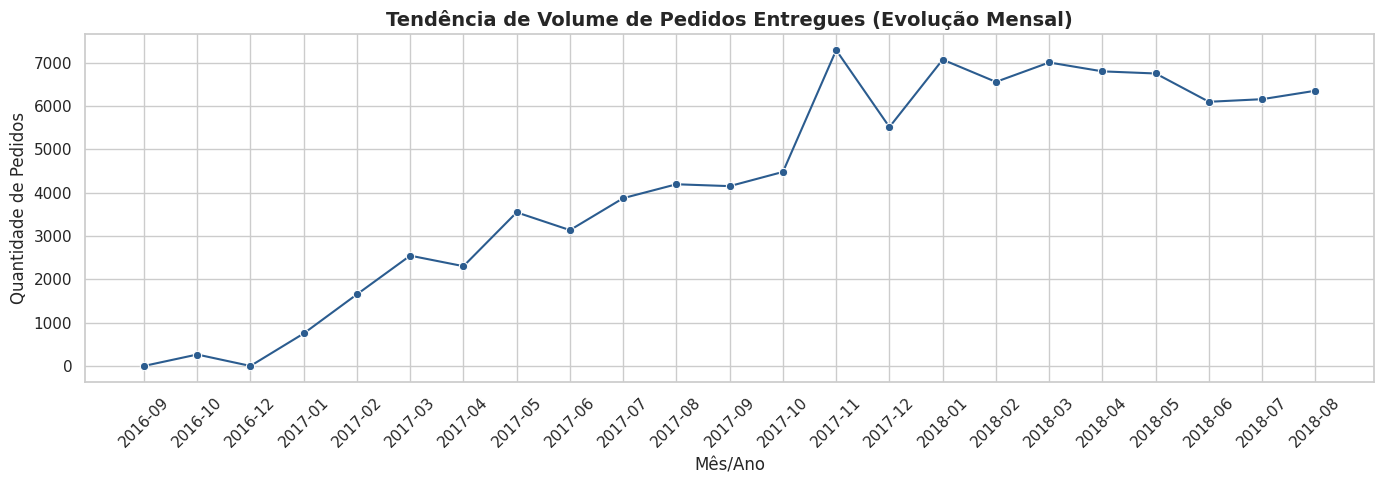

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuração visual executiva

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

print("Iniciando Análise Exploratória de Negócios...")

# ==============================================================
# Pergunta 1
# ==============================================================
# Agrupando por mês/ano usando a data de compra
df_main['ano_mes_compra'] = df_main['data_compra'].dt.to_period('M')
tendencia_pedidos = df_main.groupby('ano_mes_compra')['id_pedido'].nunique().reset_index()
tendencia_pedidos['ano_mes_compra'] = tendencia_pedidos['ano_mes_compra'].astype(str)
plt.figure(figsize=(14,5))
sns.lineplot(data=tendencia_pedidos, x='ano_mes_compra', y='id_pedido', marker='o', color='#2b5c8f')
plt.title('Tendência de Volume de Pedidos Entregues (Evolução Mensal)', fontsize=14, fontweight='bold')
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### PERGUNTA 2: Custo médio de frete e variaçao geográfica (5 Regiões)

Limpeza concluída. Novo frete médio: R$ 19.23


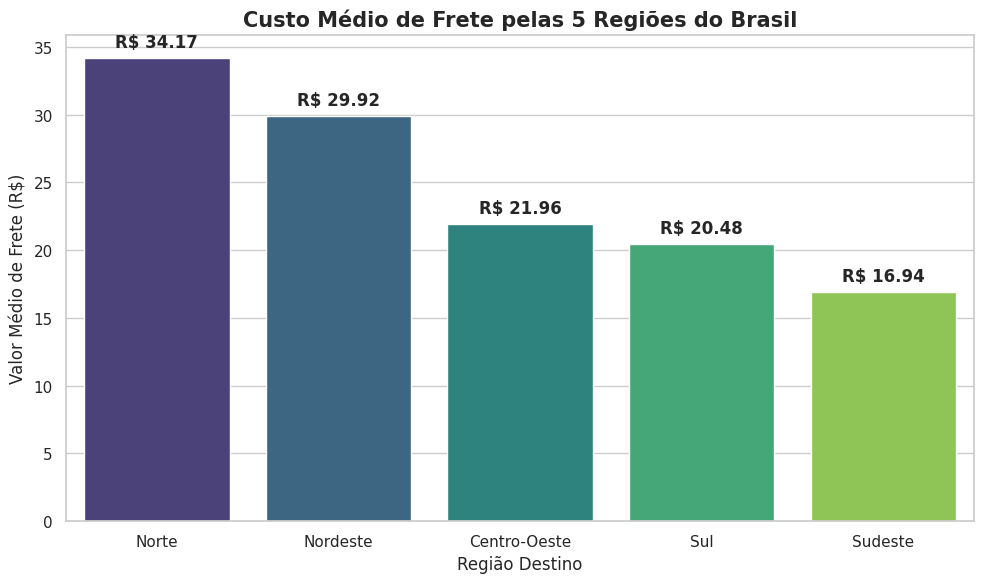

In [19]:
from matplotlib.artist import get
# 1. Mapeamento oficial das regiões do IBGE

mapa_regioes = {
    # Norte
    'AM': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'PA': 'Norte',
    'TO': 'Norte', 'RO': 'Norte', 'AC': 'Norte',

    # Nordeste
    'MA': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'RN': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste',
    'BA': 'Nordeste',

    # Centro-Oeste
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste',

    # Sudeste
    'SP': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'ES': 'Sudeste',

    # Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Criando a nova coluna E tratando nulos (ANTES de agrupar)
df_main['regiao_brasil'] = df_main['estado_cliente'].map(mapa_regioes).fillna('Outros/Não Informado')

# Limpeza de Outliers de Frete
# Remover fretes bizarros acima de 100 reais para não distorcer as médias.
df_main = df_main[df_main['valor_frete'] <= 100].copy()

print(f"Limpeza concluída. Novo frete médio: R$ {df_main['valor_frete'].mean():.2f}")

# Agrupando o valor do frete por Região e ordenando do mais caro para o mais barato
frete_regiao = df_main.groupby('regiao_brasil')['valor_frete'].mean().reset_index()
frete_regiao = frete_regiao.sort_values(by='valor_frete', ascending=False)

# Plotagem Executiva
plt.figure(figsize=(10,6))
ax = sns.barplot(data=frete_regiao, x='regiao_brasil', y='valor_frete', hue='regiao_brasil', palette='viridis')
plt.title('Custo Médio de Frete pelas 5 Regiões do Brasil', fontsize=15, fontweight='bold')
plt.xlabel('Região do Brasil', fontsize=12)
plt.xlabel('Região Destino', fontsize=12)
plt.ylabel('Valor Médio de Frete (R$)', fontsize=12)

# Adicionando os rótulos dos dados
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():.2f}', (p.get_x() + p.get_width() / 2.,p.get_height()), ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0,5), textcoords='offset points')
plt.tight_layout()
plt.show()


### PERGUNTA 3: Impacto Real da Demora na Nota do Cliente

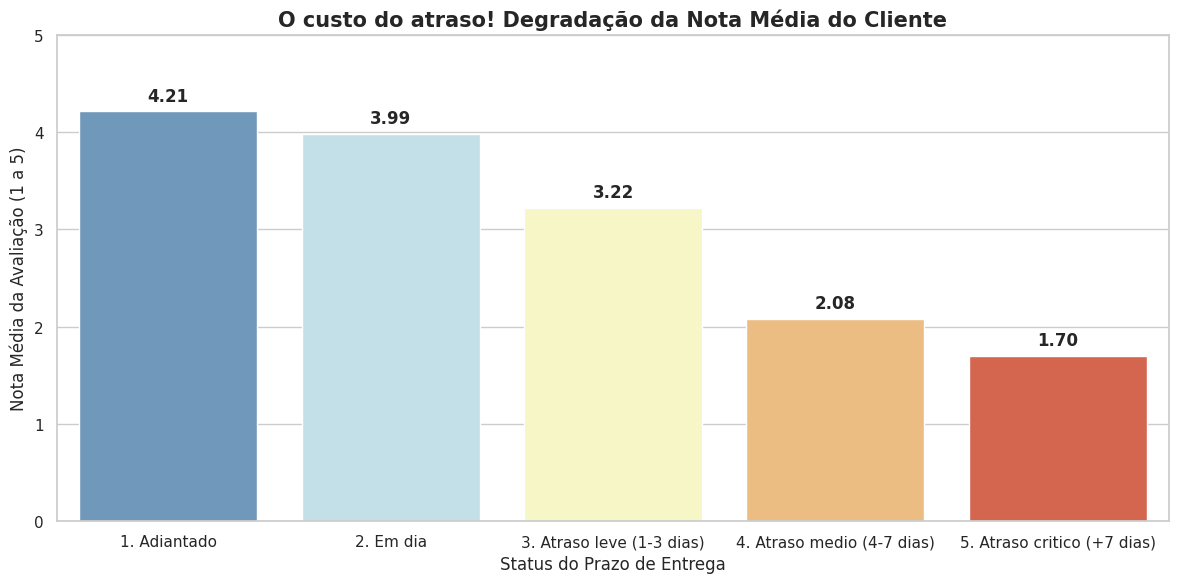

In [20]:
# 1. Criando faixas (buckets) de atraso para facilitar a leitura executiva

def categorizar_atraso(dias):
    if dias < 0:
      return '1. Adiantado'
    elif dias == 0:
      return '2. Em dia'
    elif 1<= dias <= 3:
      return '3. Atraso leve (1-3 dias)'
    elif 4 <= dias <= 7:
      return '4. Atraso medio (4-7 dias)'
    else:
      return '5. Atraso critico (+7 dias)'

df_main['faixa_atraso'] = df_main['atraso_entrega_dias'].apply(categorizar_atraso)


# 2. Agrupando para calcular a nota média por faixa

impacto_nota = df_main.groupby('faixa_atraso')['nota_avaliacao'].mean().reset_index()

plt.figure(figsize=(12,6))

# 3. Usando uma paleta de cores semântica (Azul = Bom, Vermelho = Ruim)

ax = sns.barplot(data=impacto_nota, x='faixa_atraso', y='nota_avaliacao', hue='faixa_atraso', palette='RdYlBu_r')
plt.title('O custo do atraso! Degradação da Nota Média do Cliente', fontsize=15, fontweight='bold')
plt.xlabel('Status do Prazo de Entrega', fontsize=12)
plt.ylabel('Nota Média da Avaliação (1 a 5)', fontsize=12)
plt.ylim(0,5)

# Adicionando os rótulos de dados no topo das barras

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0,5), textcoords='offset points')

plt.tight_layout()
plt.show()


### Pergunta 4: Performance de Catálogo (Piores Notas vs Frete)

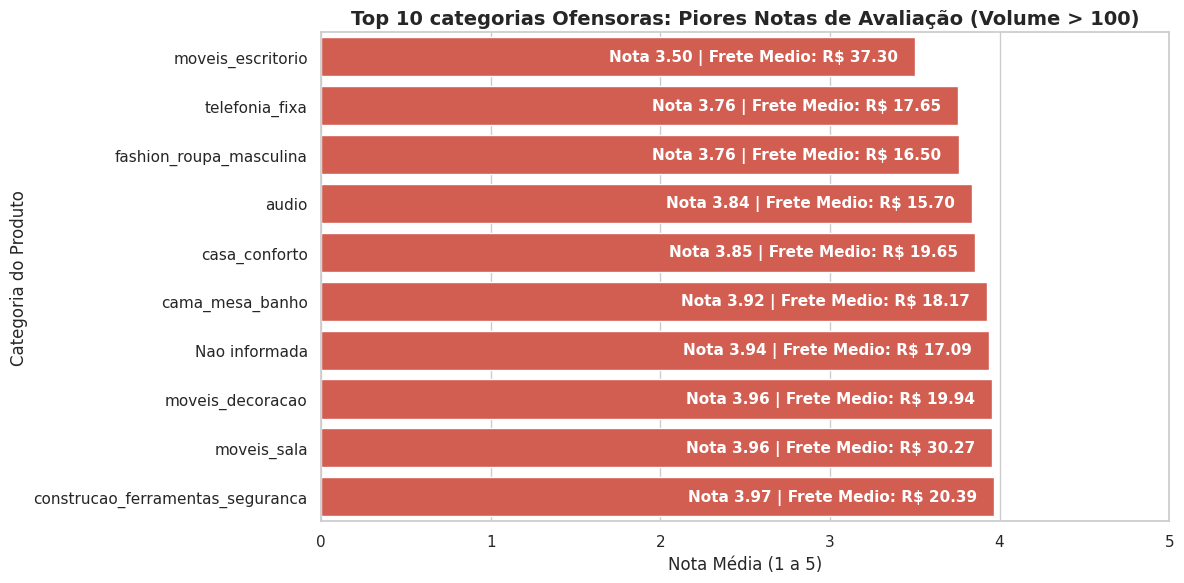

In [21]:
# Filtrando apenas categorias com volume relevante (mais de 100 pedidos) para ter significância estatistica

volume_categoria = df_main['categoria_produto'].value_counts()
categorias_relevantes = volume_categoria[volume_categoria > 100].index

df_categorias = df_main[df_main['categoria_produto'].isin(categorias_relevantes)]

#Agrupando a nota média e o frete médio por categoria
analise_catalogo = df_categorias.groupby('categoria_produto').agg(
    nota_media=('nota_avaliacao', 'mean'), frete_medio=('valor_frete', 'mean'), volume_pedidos=('id_pedido','count')
    ).reset_index()

# Ordenando pelas 10 piores notas

piores_categorias = analise_catalogo.sort_values(by='nota_media', ascending=True).head(10)

plt.figure(figsize=(12,6))
ax1 = sns.barplot(data=piores_categorias, x='nota_media', y='categoria_produto', color='#e74c3c')
plt.title('Top 10 categorias Ofensoras: Piores Notas de Avaliação (Volume > 100)', fontsize=14, fontweight='bold')
plt.xlabel('Nota Média (1 a 5)', fontsize=12)
plt.ylabel('Categoria do Produto', fontsize=12)
plt.xlim(0,5)

# Adicionando o Custo do Frete como anotação em cada barra

for i, p in enumerate(ax1.patches):
  frete = piores_categorias.iloc[i]['frete_medio']
  ax1.annotate(f'Nota {p.get_width():.2f} | Frete Medio: R$ {frete:.2f}', (p.get_width() -0.1, p.get_y() + p.get_height() / 2), ha='right', va='center', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


#

In [22]:
# Exportação MASTER PARA O LOOKER STUDIO (VERSÃO FINAL)

# 1. Seleção das colunas estratégicas

colunas_looker = [
    'id_pedido',
    'data_compra',
    'data_entrega_cliente',
    'regiao_brasil',
    'estado_cliente',
    'cidade_cliente',
    'categoria_produto',
    'preco_produto',
    'valor_frete',
    'nota_avaliacao',
    'atraso_entrega_dias',
    'faixa_atraso'

]

df_looker = df_main[colunas_looker].copy()

# 2. Garantindo tipos numéricos (evita que o Looker entenda como 'texto')
df_looker['nota_avaliacao'] = pd.to_numeric(df_looker['nota_avaliacao'], errors='coerce')
df_looker['preco_produto'] = pd.to_numeric(df_looker['preco_produto'], errors='coerce')
df_looker['valor_frete'] = pd.to_numeric(df_looker['valor_frete'], errors='coerce')
df_looker['atraso_entrega_dias'] = pd.to_numeric(df_looker['atraso_entrega_dias'], errors='coerce')

# 3. Formatando Datas para reconhecimento automático no Looker (YYYYMMDD)
# Este formato é o mais 'amigável' para evitar erros de PARSE_DATE
df_looker['data_compra'] = df_looker['data_compra'].dt.strftime('%Y%m%d')
df_looker['data_entrega_cliente'] = df_looker['data_entrega_cliente'].dt.strftime('%Y%m%d')

#4. Exportando para CSV
nome_arquivo = 'olist_dataset_looker_final.csv'
df_looker.to_csv(nome_arquivo, index=False, encoding='utf-8')
print(f"SUCESSO! O arquivo {nome_arquivo} foi gerado!")



SUCESSO! O arquivo olist_dataset_looker_final.csv foi gerado!
